In [17]:
# Third party imports.
from matplotlib import pyplot
from langchain_core.load import loads

# Local imports.
from backend.main import start

In [18]:
task = """
Generate a report about cyber security news from the past week.
"""

start(file_name="experiments.yaml", task=task)

[2025-11-24 13:56:47,058 E 882536 935818] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


In [19]:
# Define the prices of each model. 
# - Currently, only have token costs from OpenAI. Need to get other providers.
# - This data was last collected on 2025-11-18.
PRICES = {
    "gpt-4o-2024-08-06": {
        "input": 3.75 / 1_000_000,
        "output": 15.00 / 1_000_000,
    },
    "gpt-4.1-2025-04-14": {
        "input": 3.00 / 1_000_000,
        "output": 12.00 / 1_000_000,
    },
    "gpt-5-2025-08-07": {
        "input": 1.25 / 1_000_000,
        "output": 10.00 / 1_000_000,
    },
}

In [20]:
# Save the results of each experiment in a Python list.
experiments = []
with open(file="results.ndjson", mode="r", encoding="UTF-8") as input_file:
    for line in input_file.readlines():
        object = loads(line)
        experiments.append(object)

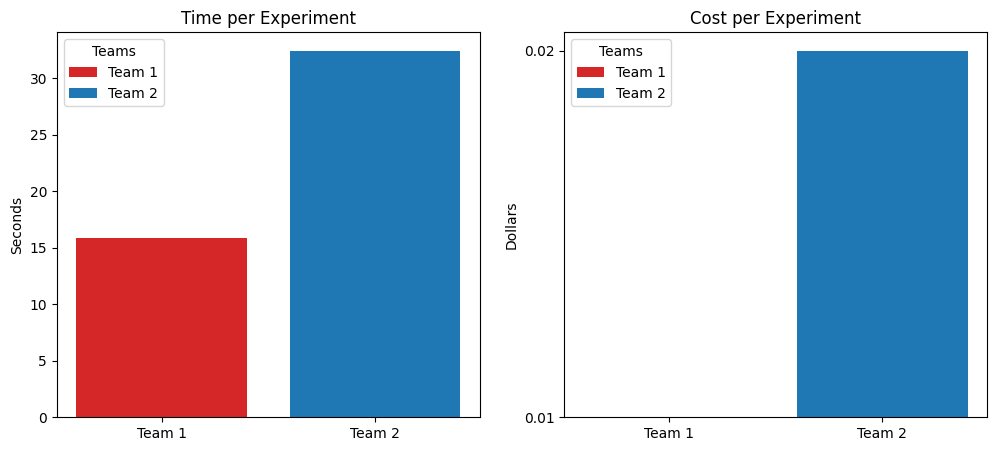

In [29]:
# Init the figure and the charts it will contain.
figure, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(12, 5))

# Get data for the "Time per Experiments" chart.
time_chart_names = []
time_chart_times = []
for experiment in experiments:
    time_chart_names.append(experiment["name"])
    time_chart_times.append(float(experiment["time_taken"]))

# Build the "Time per Experiments" chart.
ax1.bar(
    time_chart_names,
    time_chart_times,
    label=time_chart_names,
    color=["tab:red", "tab:blue", "tab:orange"]
)
ax1.set_ylabel("Seconds")
ax1.set_title("Time per Experiment")
ax1.legend(title="Teams")

# Get data for the "Cost of Experiments" chart.
cost_of_experiments = {}
for experiment in experiments:
    costs = []
    for message in experiment["messages"]:
        if message.type == "ai":
            model_name = message.response_metadata["model_name"]
            prompt_tokens = message.response_metadata["token_usage"]["prompt_tokens"]
            prompt_cost = prompt_tokens * PRICES[model_name]["output"]
            completion_tokens = message.response_metadata["token_usage"]["completion_tokens"]
            completion_cost = completion_tokens * PRICES[model_name]["output"]
            costs.append(prompt_cost + completion_cost)
    cost_of_experiments[experiment["name"]] = f"{sum(costs):.2f}"

# Build the "Cost of Experiments" chart.
ax2.bar(
    cost_of_experiments.keys(),
    cost_of_experiments.values(),
    label=cost_of_experiments.keys(),
    color=["tab:red", "tab:blue", "tab:orange"]
)
ax2.set_ylabel("Dollars")
ax2.set_title("Cost per Experiment")
ax2.legend(title="Teams")

# Show the figure.
pyplot.show()